In [2]:
import pandas as pd

In [4]:
df=pd.read_csv('UpdatedResumeDataSet.csv')

In [8]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [10]:
df.shape

(962, 2)

### Exploring Categories

In [13]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

In [15]:
import matplotlib.pyplot as plt

In [17]:
import seaborn as sns

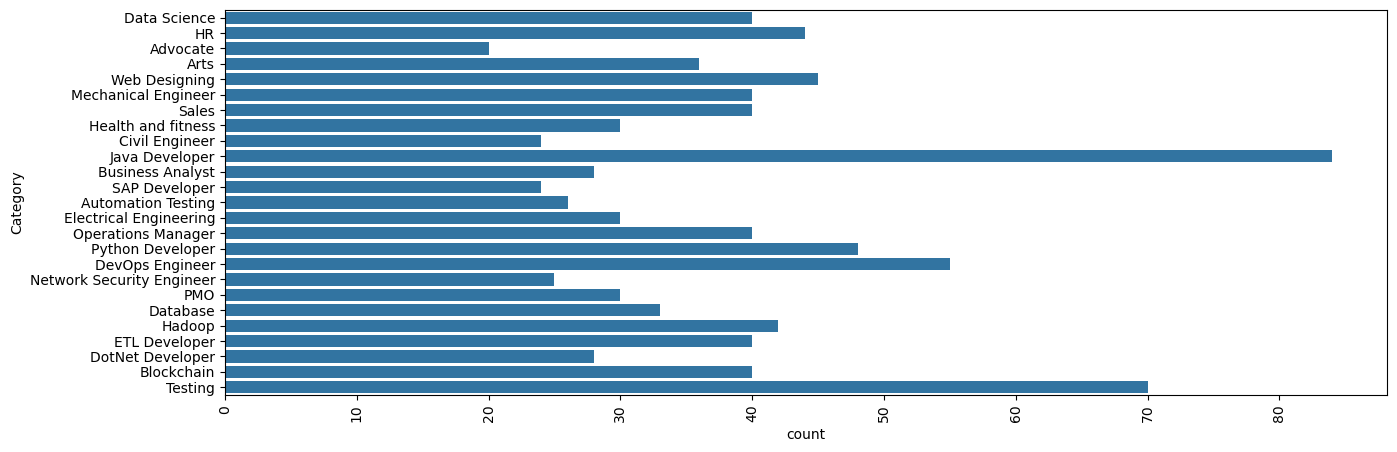

In [20]:
plt.figure(figsize=(15,5))
sns.countplot(df['Category'])
plt.xticks(rotation=90)
plt.show()

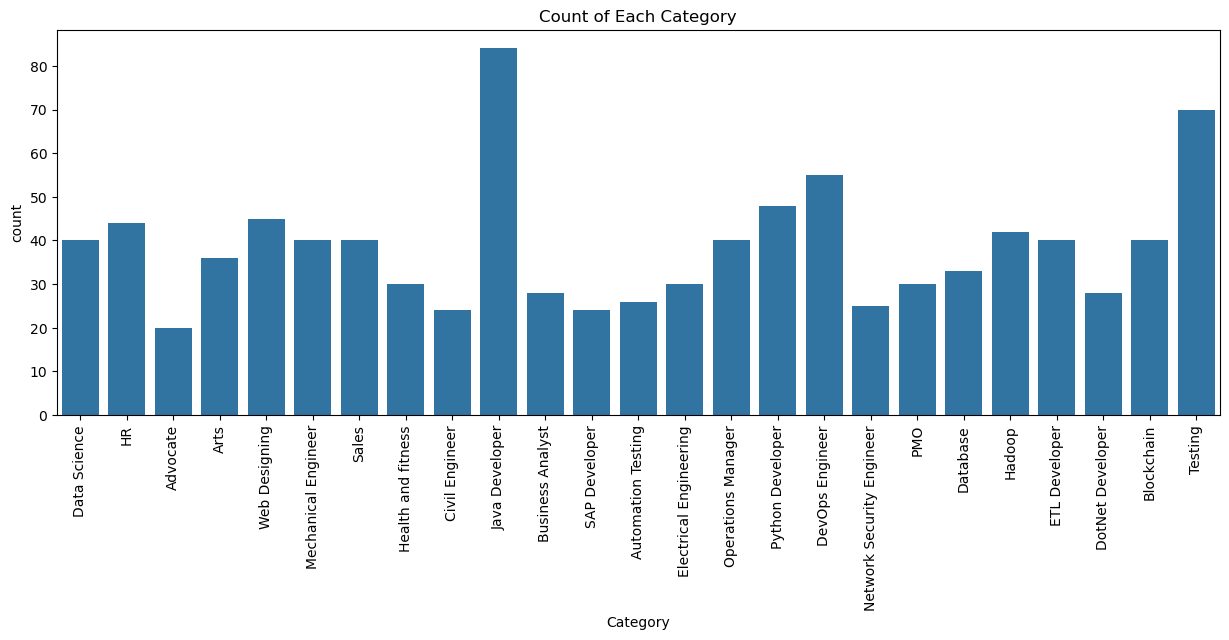

In [22]:
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x='Category')  # 👈 ye best practice hai
plt.xticks(rotation=90)
plt.title("Count of Each Category")  # optional title for clarity
plt.show()

In [28]:
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

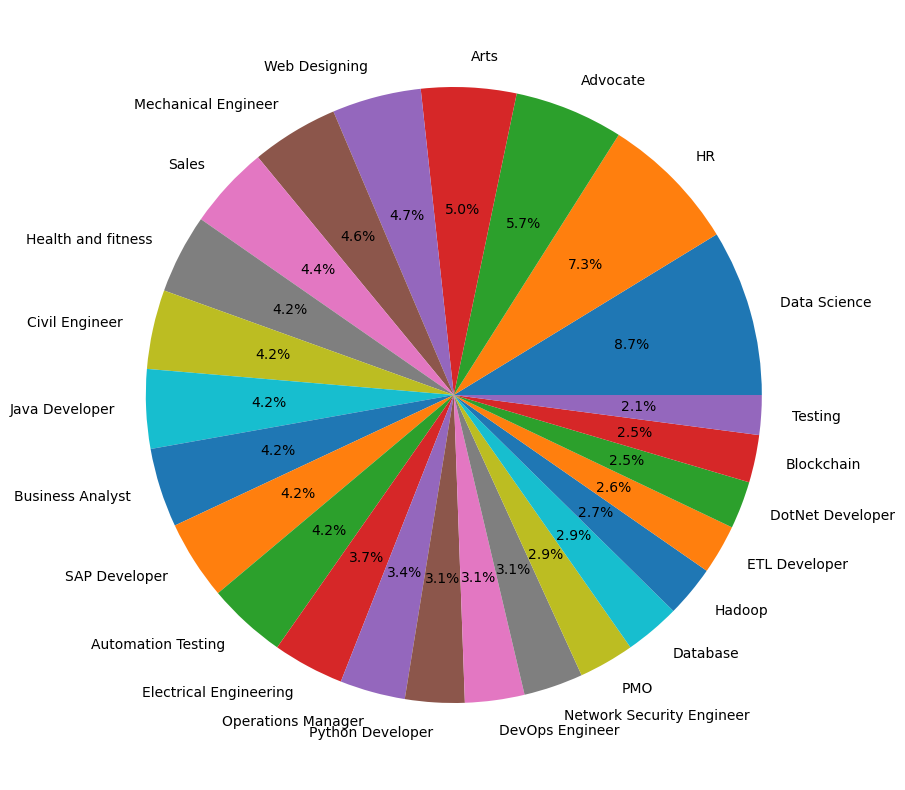

In [36]:
counts=df['Category'].value_counts()
labels=df['Category'].unique()
plt.figure(figsize=(15,10))
plt.pie(counts,labels=labels,autopct='%1.1f%%')
plt.show()

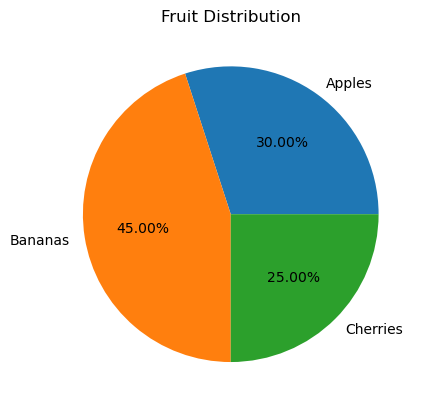

In [42]:
import matplotlib.pyplot as plt

labels = ['Apples', 'Bananas', 'Cherries']
sizes = [30, 45, 25]

plt.pie(sizes, labels=labels, autopct='%1.2f%%')
plt.title("Fruit Distribution")
plt.show()


### Exploring Resume

In [51]:
df['Category'][100]

'Advocate'

In [53]:
df['Resume'][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

### Balance Classes (Categories)

In [60]:
# Check the original category distribution
print("Original Category Distribution:")
print(df['Category'].value_counts())
max_size=df['Category'].max()
max_size

Original Category Distribution:
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64


'Web Designing'

In [66]:
## Ye maximum string value return karta hai alphabetical order mein.
max_size=df['Category'].max()
max_size

'Web Designing'

In [64]:
max_size2=df['Category'].value_counts().max()
max_size2

84

In [70]:
df.shape

(962, 2)

In [74]:
balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size2, replace=True)).reset_index(drop=True)
balanced_df

C:\Users\iaman\AppData\Local\Temp\ipykernel_5552\2891654001.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size2, replace=True)).reset_index(drop=True)


,Category,Resume
0,Advocate,QUALIFICATION: Introduction to Computer EXTRAE...
1,Advocate,SKILLS â¢ Knows English as native speaker (IE...
2,Advocate,"Education Details \r\n B.Com, LL.B., Univers..."
3,Advocate,Education Details \r\n LLB. Dibrugarh Univer...
4,Advocate,Skills Legal Writing Efficient researcher Lega...
...,...,...
2095,Web Designing,Education Details \r\n B.C.A Bachelor Computer...
2096,Web Designing,"Technical Skills Web Technologies: Angular JS,..."
2097,Web Designing,"Technical Skills Web Technologies: Angular JS,..."
2098,Web Designing,"Technical Skills Web Technologies: Angular JS,..."


### Oversampling se sabko equal chance dena

In [77]:
max_size = df['Category'].value_counts().max()   # max_size = 84

In [79]:
max_size

84


Original Category Distribution:
| Category       | Count              |
| -------------- | ------------------ |
| Java Developer | 84 ✅ (sabse zyada) |
| Web Designing  | 45                 |
| Civil Engineer | 24                 |
| Advocate       | 20 ❌ (sabse kam)   |


### Oversampling
| Category       | Pehle Count | Baad mein                        |
| -------------- | ----------- | -------------------------------- |
| Java Developer | 84          | 84        ✅ already max          |
| Web Designing  | 45          | 84        ⬆️ duplicated 39 times |
| Advocate       | 20          | 84        ⬆️ duplicated 64 timeTotal categories = 25
Each one has 84 rows now →
📊 25 × 84 = 2100 rows = balanced_df.shapes |


In [ ]:
balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size2, replace=True)).reset_index(drop=True)
balanced_df

“Pura data lo, but random order mein.” Matlab 100% data le lo, lekin shuffle karke.

In [87]:
df=balanced_df.sample(frac=1).reset_index(drop=True)

df

In [91]:
# Check the balanced category distribution
print("\nBalanced Category Distribution (After Oversampling):")
print(df['Category'].value_counts())


Balanced Category Distribution (After Oversampling):
Category
DevOps Engineer              84
Electrical Engineering       84
Arts                         84
Data Science                 84
Mechanical Engineer          84
Operations Manager           84
DotNet Developer             84
Database                     84
Blockchain                   84
Web Designing                84
Network Security Engineer    84
Testing                      84
HR                           84
Health and fitness           84
PMO                          84
Business Analyst             84
Hadoop                       84
Automation Testing           84
Sales                        84
Java Developer               84
Python Developer             84
SAP Developer                84
Civil Engineer               84
Advocate                     84
ETL Developer                84
Name: count, dtype: int64


### Cleaning Data:

1 URLs,
2 hashtags,
3 mentions,
4 special letters,
5 punctuations:

Yeh function cleanResume(txt) resume text ko clean karta hai — jaise URLs, hashtags, emojis, special characters, etc. ko remove karke ek saaf text banata hai.

In [98]:
import re

### cleanText = re.sub('http\S+\s', ' ', txt)

http se start hone wale URLs ko remove karta hai.
🔍 Regex Breakdown: 'http' — pattern 'http' se start hona chahiye
\S+ — 1 ya usse zyada non-space characters (i.e., pura URL)
\s — URL ke baad ek space hona chahiye . ' ' — replace with ek single space
 "Visit my site at http://example.com for more info."
 After cleaning: "Visit my site at  for more info."

### cleanText = re.sub('RT|cc', ' ', cleanText)

cleanText = re.sub('RT|cc', ' ', cleanText)
RT (retweet) aur cc (carbon copy) ko remove karta hai (ye Twitter style ke content clean karne ke liye useful hota hai).
🔍 Regex Breakdown:RT|cc — yahaan | ka matlab OR hai. Dono me se koi bhi mile, hata do.
txt = "RT Please share this with cc your friends"
 After cleaning: " Please share this with  your friends"

### cleanText = re.sub('#\S+\s', ' ', cleanText)

Hashtags (like #developer, #job) ko remove karta hai.🔍 Regex Breakdown:# — hashtag symbol
\S+ — 1 ya zyada non-space characters (i.e., tag name)
\s — uske baad space hona chahiye
txt = "Looking for a job #developer now!"
After cleaning: "Looking for a job  now!"

### cleanText = re.sub('@\S+', '  ', cleanText)

Mentions (jaise @username) ko remove karta hai.
🔍 Regex Breakdown: @ — at the rate symbol
\S+ — uske baad 1 ya zyada non-space characters
txt = "Thanks @Anshu for your help!"
 After cleaning: "Thanks   for your help!"

### cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)

Sabhi special characters ko remove karta hai.
🔍 Concepts: re.escape(...) — har special character ko escape karta hai, jaise . * ? etc.
'[%s]' % ... — square brackets ke andar likhe sab characters individually match karte hain.
Replace them with ' ' (space)
txt = "Hi! I'm #Anshu@123, working @OpenAI."
 After cleaning: "Hi  I m  Anshu 123 working  OpenAI "

In [ ]:
cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)

Sabhi non-ASCII characters (emoji, accented letters, foreign symbols) hata deta hai.
🔍 Regex Breakdown: [^\x00-\x7f] — characters jo ASCII range (0 to 127) ke bahar hain (i.e., emojis, é, ₹, etc.)
^ inside square brackets means NOT
txt = "My salary is ₹50000 😊"
 After cleaning: "My salary is 50000  "

In [ ]:
cleanText = re.sub('\s+', ' ', cleanText) #\s+ — one or more whitespace characters (space, tab, newline) . ' ' — single space se replace karta hai

| Regex Pattern  | Purpose                     | Example Match        |            |
| -------------- | --------------------------- | -------------------- | ---------- |
| `http\S+\s`    | Remove URLs                 | `http://abc.com `    |            |
| \`RT           | cc\`                        | Remove retweet/cc    | `RT`, `cc` |
| `#\S+\s`       | Remove hashtags             | `#developer `        |            |
| `@\S+`         | Remove mentions             | `@anshu`             |            |
| `[%s]`         | Remove punctuations         | `!`, `@`, `#`, `&`   |            |
| `[^\x00-\x7f]` | Remove emojis/foreign chars | `₹`, `😊`, `é`       |            |
| `\s+`          | Normalize whitespace        | multiple spaces/tabs |            |


In [127]:
import re

def cleanResume(txt):
    cleanText = re.sub(r'http\S+\s', ' ', txt)
    cleanText = re.sub(r'RT|cc', ' ', cleanText)
    cleanText = re.sub(r'#\S+\s', ' ', cleanText)
    cleanText = re.sub(r'@\S+', '  ', cleanText)  
    cleanText = re.sub(r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"""), ' ', cleanText)

    cleanText = re.sub(r'\s+', ' ', cleanText)
    return cleanText


In [129]:
cleanResume("my #### $ #  #noorsaeed webiste like is this http://heloword and access it @gmain.com")

'my webiste like is this and a ess it '

In [131]:
df['Resume'] = df['Resume'].apply(lambda x: cleanResume(x))

In [133]:
df['Resume'][0]

'Software Proficiency â\x80¢ Languages Basics of C SQL PL SQL JAVA JAVAEE Javascript HTML CSS jquery mysql Spring Hibernate â\x80¢ Software Tools Xillinx Modelsim Matlab Multisim â\x80¢ Operating Systems Windows XP Vista 07 08 Ubuntu Project Profile B E Project FPGA Implementation of Team Size 4 Role Programmer AES Algorithm AES is Advanced Encryption Standard which is used in cryptography by which we can protect our data It encrypted by a Secret Key T E project Sorting Robot Team Size 3 Role Mechanism designer The TCS 230 sensor sorts the RGB color balls a ording to their color Diploma Project RFID Based Student Team Size 4 Role Interface Attendance System Using GSM In this student show RFID card of his own and then message send via GSM to their parent that his ward is present Education Details May 2016 B E Savitribai Phule Pune Maharashtra Pune University March 2010 S S C Maharashtra Board DevOps Engineer Skill Details C Exprience 6 months C Exprience 6 months Sql Exprience 6 months 

### 
words into categorical values

In [137]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [139]:
le.fit(df['Category'])
df['Category'] = le.transform(df['Category'])

In [141]:
df.Category.unique()

array([ 8, 14,  0,  5, 21, 20, 15, 22,  2, 13,  4, 19, 12, 11, 23, 17, 24,
        3,  7,  9, 18, 16,  6,  1, 10])

## Vactorization

In [148]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')
# Creates an object that will convert text into TF-IDF vectors.
# stop_words='english' removes common English words like "the", "is", "and", etc.
tfidf.fit(df['Resume'])
#Learns the vocabulary from your resumes.
#It builds a list of all unique words (except stop words) across the entire dataset.
requredTaxt = tfidf.transform(df['Resume'])

TF (Term Frequency): How often a word appears in a document.
IDF (Inverse Document Frequency): How rare the word is across all documents.
Together, TF-IDF tells you how important a word is in a particular document (resume), while discounting common words that appear in every resume.



In [151]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

df1 = pd.DataFrame({
    'Resume': [
        "I am a software engineer with experience in Python and machine learning.",
        "Experienced data analyst skilled in SQL, Excel, and data visualization.",
        "Machine learning and deep learning enthusiast with Python skills."
    ]
})


In [153]:
tfidf = TfidfVectorizer(stop_words='english') #This removes common stopwords like in, and, with, etc

In [155]:
tfidf.fit(df['Resume'])

TfidfVectorizer(stop_words='english')

In [157]:
tfidf.fit(df1['Resume'])

TfidfVectorizer(stop_words='english')

In [159]:
df1['Resume']

0    I am a software engineer with experience in Py...
1    Experienced data analyst skilled in SQL, Excel...
2    Machine learning and deep learning enthusiast ...
Name: Resume, dtype: object

In [161]:
# 🔸 Print vocabulary words
print(tfidf.get_feature_names_out())

['analyst' 'data' 'deep' 'engineer' 'enthusiast' 'excel' 'experience'
 'experienced' 'learning' 'machine' 'python' 'skilled' 'skills' 'software'
 'sql' 'visualization']


In [163]:
tfidf.fit(df['Resume'])

TfidfVectorizer(stop_words='english')

In [165]:
print(tfidf.get_feature_names_out())

['000' '01' '017' ... 'zz' 'ã¼' 'ã¼â']


In [167]:
print(df['Resume'][0][:1000])  # Print first 1000 characters to inspect


Software Proficiency â¢ Languages Basics of C SQL PL SQL JAVA JAVAEE Javascript HTML CSS jquery mysql Spring Hibernate â¢ Software Tools Xillinx Modelsim Matlab Multisim â¢ Operating Systems Windows XP Vista 07 08 Ubuntu Project Profile B E Project FPGA Implementation of Team Size 4 Role Programmer AES Algorithm AES is Advanced Encryption Standard which is used in cryptography by which we can protect our data It encrypted by a Secret Key T E project Sorting Robot Team Size 3 Role Mechanism designer The TCS 230 sensor sorts the RGB color balls a ording to their color Diploma Project RFID Based Student Team Size 4 Role Interface Attendance System Using GSM In this student show RFID card of his own and then message send via GSM to their parent that his ward is present Education Details May 2016 B E Savitribai Phule Pune Maharashtra Pune University March 2010 S S C Maharashtra Board DevOps Engineer Skill Details C Exprience 6 months C Exprience 6 months Sql Exprience 6 months Pl Sql Exp

In [169]:
import re

def cleanResume(txt):
    try:
        # Fix encoding
        txt = txt.encode('latin1').decode('utf-8')  # fix â€¢ etc.
    except:
        pass  # skip if decode fails

    txt = re.sub(r'http\S+', ' ', txt)              # remove URLs
    txt = re.sub(r'[^a-zA-Z\s]', ' ', txt)          # remove everything except alphabets and spaces
    txt = re.sub(r'\s+', ' ', txt)                  # collapse multiple spaces
    txt = txt.lower()                               # convert to lowercase
    return txt


In [171]:
df['Clean_Resume'] = df['Resume'].apply(cleanResume)


In [173]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf.fit(df['Clean_Resume'])

print(tfidf.get_feature_names_out())  # cleaner words


['aaa' 'ab' 'abacus' ... 'zhypility' 'zone' 'zz']


In [175]:
from sklearn.model_selection import train_test_split

In [184]:
#requredTaxt: This is your input feature matrix, i.e., the TF-IDF-transformed resumes.
#df['Category']: This is your target label, i.e., the job role/category for each resume.
X_train, X_test, y_train, y_test = train_test_split(requredTaxt, df['Category'], test_size=0.2, random_state=42)

In [179]:
X_train.shape

(1680, 7382)

In [181]:
X_test.shape

(420, 7382)

### Now let’s train the model and print the classification report:

We already converted your resume texts into numerical TF-IDF vectors (features) and you have the job categories as labels.
Now you need a machine learning algorithm that can learn patterns from resumes and predict the job category for new/unseen resumes.
That’s where classifiers like K-Nearest Neighbors (KNN) come in.

Intuition:
KNN looks at the 'K' most similar resumes (nearest neighbors) to a new resume. Based on their categories, it decides what category the new resume should belong to.

In [190]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier

KNeighborsClassifier() is the algorithm.
OneVsRestClassifier() wraps it to handle multi-class classification (if you have more than 2 categories like Java, Python, DevOps, etc.).



In [195]:
# Convert sparse matrix to dense (required for some models like KNN, Naive Bayes)
X_train = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_test = X_test.toarray() if hasattr(X_test, 'toarray') else X_test


TF-IDF output is usually sparse, but KNN needs dense arrays. So we convert it using .toarray() if necessary.

In [198]:
knn_model = OneVsRestClassifier(KNeighborsClassifier())
knn_model.fit(X_train, y_train)


OneVsRestClassifier(estimator=KNeighborsClassifier())

In [200]:
y_pred_knn = knn_model.predict(X_test)


In [202]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\nKNeighborsClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_knn)}")


KNeighborsClassifier Results:
Accuracy: 0.9929
Confusion Matrix:
[[15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  1  0  0  0  0  0 14  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   1]
 [ 0  0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  

accuracy_score: percentage of correct predictions . 
confusion_matrix: how many times each category was correctly or wrongly predicted . 
classification_report: shows precision, recall, f1-score for each class (useful for imbalance)

In [236]:
from sklearn.svm import SVC


 SVC finds the best boundary between these categories.
Goal: "Ek aisi line/plane (boundary) dhoondho jo different categories ko sabse acchi tarah separate kare."

In [ ]:
# 2. Train SVC
svc_model = OneVsRestClassifier(SVC())
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)
print("\nSVC Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_svc)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_svc)}")

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [229]:
# Function to predict the category of a resume
def pred(input_resume):
    # Preprocess the input text (e.g., cleaning, etc.)
    cleaned_text = cleanResume(input_resume) 

    # Vectorize the cleaned text using the same TF-IDF vectorizer used during training
    vectorized_text = tfidf.transform([cleaned_text])
    
    # Convert sparse matrix to dense
    vectorized_text = vectorized_text.toarray()

    # Prediction
    predicted_category = svc_model.predict(vectorized_text)

    # get name of predicted category
    predicted_category_name = le.inverse_transform(predicted_category)

    return predicted_category_name[0]  # Return the category name